# NYC Motor Vehicle Collisions — Exploratory Analysis
### nyc-crashes-exploration | Initial Data Wrangling

In [1]:
## Import Libraries

import pandas as pd
import numpy as np


In [3]:
## Load the Dataset
df = pd.read_csv('../data/nyc_crashes.csv')

print("Dataset loaded successfully!")


C:\Users\snaya\AppData\Local\Temp\ipykernel_29004\3018818061.py:2: DtypeWarning: Columns (0: ZIP CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/nyc_crashes.csv')


Dataset loaded successfully!


## First Look at the Data

In [4]:
# Preview first few rows
df.head()


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230.0,40.62179,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN


In [5]:
# Check dimensions
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Shape: (2262089, 29)
Rows: 2,262,089
Columns: 29


In [6]:
# Data types and missing values overview
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2262089 entries, 0 to 2262088
Data columns (total 29 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     str    
 1   CRASH TIME                     str    
 2   BOROUGH                        str    
 3   ZIP CODE                       object 
 4   LATITUDE                       float64
 5   LONGITUDE                      float64
 6   LOCATION                       str    
 7   ON STREET NAME                 str    
 8   CROSS STREET NAME              str    
 9   OFF STREET NAME                str    
 10  NUMBER OF PERSONS INJURED      float64
 11  NUMBER OF PERSONS KILLED       float64
 12  NUMBER OF PEDESTRIANS INJURED  int64  
 13  NUMBER OF PEDESTRIANS KILLED   int64  
 14  NUMBER OF CYCLIST INJURED      int64  
 15  NUMBER OF CYCLIST KILLED       int64  
 16  NUMBER OF MOTORIST INJURED     int64  
 17  NUMBER OF MOTORIST KILLED      int64  
 18  CONTRIBUTING 

### Explore Individual Columns

In [7]:
# Statistical summary of numerical columns
df.describe()

,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,COLLISION_ID
count,2.021328e+06,2.021328e+06,2.262071e+06,2.260249e+06,2.262089e+06,2.262089e+06,2.262089e+06,2.262089e+06,2.262089e+06,2.262089e+06,2.262089e+06
mean,4.057434e+01,-7.365500e+01,3.323715e-01,1.599824e-03,6.060637e-02,7.935143e-04,2.952183e-02,1.286422e-04,2.374597e-01,6.458632e-04,3.295427e+06
std,2.464279e+00,4.567583e+00,7.178429e-01,4.220563e-02,2.519372e-01,2.877934e-02,1.715778e-01,1.138024e-02,6.790492e-01,2.776678e-02,1.511231e+06
min,0.000000e+00,-2.013600e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.200000e+01
25%,4.066724e+01,-7.397448e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.201643e+06
50%,4.072017e+01,-7.392655e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.767361e+06
75%,4.076963e+01,-7.386639e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.333082e+06
max,4.334444e+01,0.000000e+00,4.300000e+01,8.000000e+00,2.700000e+01,6.000000e+00,4.000000e+00,2.000000e+00,4.300000e+01,5.000000e+00,4.898914e+06


In [8]:
# clean names of column
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [9]:
# Most common boroughs where crashes happen
df['borough'].value_counts()

borough
BROOKLYN         504965
QUEENS           421043
MANHATTAN        347382
BRONX            233228
STATEN ISLAND     65815
Name: count, dtype: int64

In [10]:
# Top contributing factors to crashes
df['contributing_factor_vehicle_1'].value_counts().head(10)


contributing_factor_vehicle_1
Unspecified                       754697
Driver Inattention/Distraction    460488
Failure to Yield Right-of-Way     135619
Following Too Closely             121316
Backing Unsafely                   82388
Other Vehicular                    71134
Passing or Lane Usage Improper     65248
Passing Too Closely                57784
Turning Improperly                 55566
Fatigued/Drowsy                    47594
Name: count, dtype: int64

In [11]:
# Most involved vehicle types
df['vehicle_type_code_1'].value_counts().head(10)


vehicle_type_code_1
Sedan                                  659929
Station Wagon/Sport Utility Vehicle    516692
PASSENGER VEHICLE                      416206
SPORT UTILITY / STATION WAGON          180291
Taxi                                    57145
4 dr sedan                              40954
Pick-up Truck                           39291
TAXI                                    31911
Box Truck                               27179
VAN                                     25266
Name: count, dtype: int64

### Basic Cleaning

In [12]:
### Check for Missing Values
# Count missing values per column
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct
})

print(missing_summary[missing_summary['Missing Values'] > 0])



                               Missing Values  Percentage (%)
vehicle_type_code_5                   2252147           99.56
contributing_factor_vehicle_5         2251824           99.55
vehicle_type_code_4                   2225990           98.40
contributing_factor_vehicle_4         2224616           98.34
vehicle_type_code_3                   2104770           93.05
contributing_factor_vehicle_3         2098276           92.76
off_street_name                       1857585           82.12
cross_street_name                      866886           38.32
zip_code                               689941           30.50
borough                                689656           30.49
on_street_name                         496878           21.97
vehicle_type_code_2                    460778           20.37
contributing_factor_vehicle_2          367456           16.24
location                               240761           10.64
latitude                               240761           10.64
longitud

In [13]:
### Check for Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


In [14]:
# Drop duplicates if any
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")


Shape after removing duplicates: (2262089, 29)


In [15]:
### Rename Columns for Clarity
df.rename(columns={
    'crash_date'                    : 'date',
    'crash_time'                    : 'time',
    'number_of_persons_injured'     : 'injured',
    'number_of_persons_killed'      : 'killed',
    'contributing_factor_vehicle_1' : 'main_cause',
    'vehicle_type_code1'            : 'vehicle_type',
    'collision_id'                  : 'id'
}, inplace=True)

print("Columns renamed successfully!")
df.head(2)


Columns renamed successfully!


,date,time,borough,zip_code,latitude,longitude,location,on_street_name,cross_street_name,off_street_name,...,contributing_factor_vehicle_2,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,id,vehicle_type_code_1,vehicle_type_code_2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN


### Fix Data Types

In [16]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])


In [17]:
# Ensure injured/killed are numeric
df['injured'] = pd.to_numeric(df['injured'], errors='coerce')
df['killed']  = pd.to_numeric(df['killed'],  errors='coerce')

print(df[['date', 'injured', 'killed']].dtypes)


date       datetime64[us]
injured           float64
killed            float64
dtype: object


### Drop Unnecessary Columns

In [18]:
# Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df):,}  →  {len(df):,} rows remain")

Duplicates removed: 0  →  2,262,089 rows remain


In [19]:
# Drop columns with too many missing values or low analytical value
cols_to_drop = [
    'location',
    'cross_street_name',
    'off_street_name',
    'contributing_factor_vehicle_3',
    'contributing_factor_vehicle_4',
    'contributing_factor_vehicle_5',
    'vehicle_type_code_3',
    'vehicle_type_code_4',
    'vehicle_type_code_5'
]


In [20]:
# Only drop columns that actually exist in the df
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Remaining columns: {df.shape[1]}")
print(df.columns.tolist())


Remaining columns: 20
['date', 'time', 'borough', 'zip_code', 'latitude', 'longitude', 'on_street_name', 'injured', 'killed', 'number_of_pedestrians_injured', 'number_of_pedestrians_killed', 'number_of_cyclist_injured', 'number_of_cyclist_killed', 'number_of_motorist_injured', 'number_of_motorist_killed', 'main_cause', 'contributing_factor_vehicle_2', 'id', 'vehicle_type_code_1', 'vehicle_type_code_2']


### Filtering & Sorting

In [21]:
### Filter with Boolean Indexing — Fatal Crashes Only
fatal_crashes = df[df['killed'] > 0]
print(f"Fatal crashes: {len(fatal_crashes):,}")
fatal_crashes[['date', 'borough', 'killed', 'main_cause']].head(10)


Fatal crashes: 3,468


,date,borough,killed,main_cause
50,2021-07-09,NaN,1.0,Unspecified
159,2021-12-12,NaN,1.0,Unspecified
602,2021-04-15,BROOKLYN,1.0,Driver Inattention/Distraction
616,2021-04-15,NaN,1.0,Alcohol Involvement
1332,2021-04-17,NaN,1.0,Unsafe Speed
1362,2021-07-08,MANHATTAN,1.0,Traffic Control Disregarded
1456,2021-09-11,NaN,1.0,Pedestrian/Bicyclist/Other Pedestrian Error/Co...
2204,2021-04-18,NaN,1.0,Unspecified
2279,2021-04-18,NaN,1.0,Driver Inattention/Distraction
2358,2020-09-06,NaN,1.0,Unsafe Lane Changing


In [22]:
### Filter with .loc[] — Crashes in Brooklyn
brooklyn = df.loc[df['borough'] == 'BROOKLYN']
print(f"Crashes in Brooklyn: {len(brooklyn):,}")
brooklyn[['date', 'time', 'injured', 'main_cause']].head(5)


Crashes in Brooklyn: 504,965


,date,time,injured,main_cause
2,2023-11-01,1:29,1.0,Unspecified
9,2021-09-11,9:35,0.0,Unspecified
10,2021-12-14,8:13,0.0,NaN
14,2021-12-14,21:10,0.0,Driver Inexperience
21,2021-12-14,17:58,0.0,Passing Too Closely


In [23]:
### Filter with .iloc[] — First 5 rows, first 4 columns
df.iloc[0:5, 0:4]


,date,time,borough,zip_code
0,2021-09-11,2:39,NaN,NaN
1,2022-03-26,11:45,NaN,NaN
2,2023-11-01,1:29,BROOKLYN,11230.0
3,2022-06-29,6:55,NaN,NaN
4,2022-09-21,13:21,NaN,NaN


In [24]:
### Sort by Number of Injuries (Descending)
df.sort_values('injured', ascending=False)[
    ['date', 'borough', 'injured', 'killed', 'main_cause']
].head(10)


,date,borough,injured,killed,main_cause
1865977,2013-09-09,BROOKLYN,43.0,0.0,Unspecified
137487,2022-07-21,NaN,40.0,0.0,Unsafe Speed
222101,2023-04-07,QUEENS,34.0,0.0,Traffic Control Disregarded
1537186,2015-04-17,QUEENS,32.0,0.0,Physical Disability
967087,2017-10-10,BRONX,31.0,0.0,Aggressive Driving/Road Rage
1052517,2017-05-18,MANHATTAN,27.0,1.0,Drugs (illegal)
287923,2023-12-28,STATEN ISLAND,25.0,0.0,Aggressive Driving/Road Rage
2087961,2012-08-01,NaN,24.0,0.0,Driver Inattention/Distraction
1892054,2013-07-22,BROOKLYN,24.0,0.0,Unspecified
1584727,2015-01-07,BROOKLYN,24.0,0.0,Traffic Control Disregarded


### Early Observations & Questions

In [25]:
# Which borough has the most crashes?
print("Crashes by Borough:")
print(df['borough'].value_counts())


Crashes by Borough:
borough
BROOKLYN         504965
QUEENS           421043
MANHATTAN        347382
BRONX            233228
STATEN ISLAND     65815
Name: count, dtype: int64


In [26]:
# What is the most common cause of crashes?
print("\n Top 5 Causes:")
print(df['main_cause'].value_counts().head(5))



 Top 5 Causes:
main_cause
Unspecified                       754697
Driver Inattention/Distraction    460488
Failure to Yield Right-of-Way     135619
Following Too Closely             121316
Backing Unsafely                   82388
Name: count, dtype: int64


In [27]:
# What percentage of crashes resulted in injuries?
pct_injured = (df['injured'] > 0).mean() * 100
print(f"\n Crashes with at least 1 injury: {pct_injured:.2f}%")



 Crashes with at least 1 injury: 24.55%


In [28]:
# What percentage of crashes were fatal?
pct_fatal = (df['killed'] > 0).mean() * 100
print(f" Fatal crashes: {pct_fatal:.2f}%")


 Fatal crashes: 0.15%


###  Summary

In [29]:
print("=" * 45)
print("        PROJECT SUMMARY — NYC CRASHES")
print("=" * 45)
print(f"  Total records loaded   : {len(df):>10,}")
print(f"  Columns remaining      : {df.shape[1]:>10}")
print(f"  Date range             : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Fatal crashes          : {(df['killed'] > 0).sum():>10,}")
print(f"  Crashes with injuries  : {(df['injured'] > 0).sum():>10,}")
print("=" * 45)


        PROJECT SUMMARY — NYC CRASHES
  Total records loaded   :  2,262,089
  Columns remaining      :         20
  Date range             : 2012-07-01 → 2026-05-12
  Fatal crashes          :      3,468
  Crashes with injuries  :    555,300


## Cleaning + EDA + Visualizations

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [31]:
# Plot style 
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

### Handle missing values

In [33]:
# Borough: keep NaN but label them for aggregations
df['borough'] = df['borough'].fillna('UNKNOWN')

print(df)

              date   time   borough zip_code   latitude  longitude  \
0       2021-09-11   2:39   UNKNOWN      NaN        NaN        NaN   
1       2022-03-26  11:45   UNKNOWN      NaN        NaN        NaN   
2       2023-11-01   1:29  BROOKLYN  11230.0  40.621790 -73.970024   
3       2022-06-29   6:55   UNKNOWN      NaN        NaN        NaN   
4       2022-09-21  13:21   UNKNOWN      NaN        NaN        NaN   
...            ...    ...       ...      ...        ...        ...   
2262084 2021-04-23  13:35   UNKNOWN      NaN  40.845190 -73.911200   
2262085 2021-04-22  14:20   UNKNOWN      NaN        NaN        NaN   
2262086 2021-04-23   8:40  BROOKLYN  11212.0  40.667156 -73.910100   
2262087 2021-04-23   9:00   UNKNOWN      NaN  40.700478 -73.925340   
2262088 2021-04-23   5:08   UNKNOWN      NaN  40.739143 -73.901090   

                     on_street_name  injured  killed  \
0             WHITESTONE EXPRESSWAY      2.0     0.0   
1           QUEENSBORO BRIDGE UPPER      1.0   

In [34]:
# # Numeric injury/killed: fill NaN with 0 (no evidence of injury = 0)
df['injured'] = df['injured'].fillna(0).astype(int)
print(df)


              date   time   borough zip_code   latitude  longitude  \
0       2021-09-11   2:39   UNKNOWN      NaN        NaN        NaN   
1       2022-03-26  11:45   UNKNOWN      NaN        NaN        NaN   
2       2023-11-01   1:29  BROOKLYN  11230.0  40.621790 -73.970024   
3       2022-06-29   6:55   UNKNOWN      NaN        NaN        NaN   
4       2022-09-21  13:21   UNKNOWN      NaN        NaN        NaN   
...            ...    ...       ...      ...        ...        ...   
2262084 2021-04-23  13:35   UNKNOWN      NaN  40.845190 -73.911200   
2262085 2021-04-22  14:20   UNKNOWN      NaN        NaN        NaN   
2262086 2021-04-23   8:40  BROOKLYN  11212.0  40.667156 -73.910100   
2262087 2021-04-23   9:00   UNKNOWN      NaN  40.700478 -73.925340   
2262088 2021-04-23   5:08   UNKNOWN      NaN  40.739143 -73.901090   

                     on_street_name  injured  killed  \
0             WHITESTONE EXPRESSWAY        2     0.0   
1           QUEENSBORO BRIDGE UPPER        1   

In [35]:

df['killed']  = df['killed'].fillna(0).astype(int)
print(df)

              date   time   borough zip_code   latitude  longitude  \
0       2021-09-11   2:39   UNKNOWN      NaN        NaN        NaN   
1       2022-03-26  11:45   UNKNOWN      NaN        NaN        NaN   
2       2023-11-01   1:29  BROOKLYN  11230.0  40.621790 -73.970024   
3       2022-06-29   6:55   UNKNOWN      NaN        NaN        NaN   
4       2022-09-21  13:21   UNKNOWN      NaN        NaN        NaN   
...            ...    ...       ...      ...        ...        ...   
2262084 2021-04-23  13:35   UNKNOWN      NaN  40.845190 -73.911200   
2262085 2021-04-22  14:20   UNKNOWN      NaN        NaN        NaN   
2262086 2021-04-23   8:40  BROOKLYN  11212.0  40.667156 -73.910100   
2262087 2021-04-23   9:00   UNKNOWN      NaN  40.700478 -73.925340   
2262088 2021-04-23   5:08   UNKNOWN      NaN  40.739143 -73.901090   

                     on_street_name  injured  killed  \
0             WHITESTONE EXPRESSWAY        2       0   
1           QUEENSBORO BRIDGE UPPER        1   

In [36]:
# main_cause: replace "Unspecified" string with NaN for cleaner analysis
df['main_cause'] = df['main_cause'].replace('Unspecified', np.nan)
print(df)

              date   time   borough zip_code   latitude  longitude  \
0       2021-09-11   2:39   UNKNOWN      NaN        NaN        NaN   
1       2022-03-26  11:45   UNKNOWN      NaN        NaN        NaN   
2       2023-11-01   1:29  BROOKLYN  11230.0  40.621790 -73.970024   
3       2022-06-29   6:55   UNKNOWN      NaN        NaN        NaN   
4       2022-09-21  13:21   UNKNOWN      NaN        NaN        NaN   
...            ...    ...       ...      ...        ...        ...   
2262084 2021-04-23  13:35   UNKNOWN      NaN  40.845190 -73.911200   
2262085 2021-04-22  14:20   UNKNOWN      NaN        NaN        NaN   
2262086 2021-04-23   8:40  BROOKLYN  11212.0  40.667156 -73.910100   
2262087 2021-04-23   9:00   UNKNOWN      NaN  40.700478 -73.925340   
2262088 2021-04-23   5:08   UNKNOWN      NaN  40.739143 -73.901090   

                     on_street_name  injured  killed  \
0             WHITESTONE EXPRESSWAY        2       0   
1           QUEENSBORO BRIDGE UPPER        1   

In [37]:
# Engineer new columns

df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['day_of_week']= df['date'].dt.day_name()
df['hour']       = pd.to_datetime(df['time'], format='%H:%M', errors='coerce').dt.hour

df[['date', 'time', 'year', 'month', 'month_name', 'day_of_week', 'hour']].head(10)

,date,time,year,month,month_name,day_of_week,hour
0,2021-09-11,2:39,2021,9,Sep,Saturday,2
1,2022-03-26,11:45,2022,3,Mar,Saturday,11
2,2023-11-01,1:29,2023,11,Nov,Wednesday,1
3,2022-06-29,6:55,2022,6,Jun,Wednesday,6
4,2022-09-21,13:21,2022,9,Sep,Wednesday,13
5,2023-04-26,13:30,2023,4,Apr,Wednesday,13
6,2023-11-01,7:12,2023,11,Nov,Wednesday,7
7,2023-11-01,8:01,2023,11,Nov,Wednesday,8
8,2023-04-26,22:20,2023,4,Apr,Wednesday,22
9,2021-09-11,9:35,2021,9,Sep,Saturday,9


In [39]:
# Severity label
def severity(row):
    if row['killed'] > 0:
        return 'Fatal'
    elif row['injured'] > 0:
        return 'Injury'
    else:
        return 'Property Only'

df['severity'] = df.apply(severity, axis=1)

print(df)

              date   time   borough zip_code   latitude  longitude  \
0       2021-09-11   2:39   UNKNOWN      NaN        NaN        NaN   
1       2022-03-26  11:45   UNKNOWN      NaN        NaN        NaN   
2       2023-11-01   1:29  BROOKLYN  11230.0  40.621790 -73.970024   
3       2022-06-29   6:55   UNKNOWN      NaN        NaN        NaN   
4       2022-09-21  13:21   UNKNOWN      NaN        NaN        NaN   
...            ...    ...       ...      ...        ...        ...   
2262084 2021-04-23  13:35   UNKNOWN      NaN  40.845190 -73.911200   
2262085 2021-04-22  14:20   UNKNOWN      NaN        NaN        NaN   
2262086 2021-04-23   8:40  BROOKLYN  11212.0  40.667156 -73.910100   
2262087 2021-04-23   9:00   UNKNOWN      NaN  40.700478 -73.925340   
2262088 2021-04-23   5:08   UNKNOWN      NaN  40.739143 -73.901090   

                     on_street_name  injured  killed  \
0             WHITESTONE EXPRESSWAY        2       0   
1           QUEENSBORO BRIDGE UPPER        1   

In [40]:
# Time-of-day bucket
def time_of_day(hour):
    if pd.isna(hour):
        return 'Unknown'
    h = int(hour)
    if   6  <= h < 12: return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 21: return 'Evening'
    else:               return 'Night'

df['time_of_day'] = df['hour'].apply(time_of_day)

In [41]:
print("\n✓ Cleaning complete. New columns added: year, month, month_name,")



✓ Cleaning complete. New columns added: year, month, month_name,


In [42]:
print("  day_of_week, hour, severity, time_of_day")


  day_of_week, hour, severity, time_of_day


In [43]:
print(f"\n  Date range : {df['date'].min().date()} → {df['date'].max().date()}")



  Date range : 2012-07-01 → 2026-05-12


In [44]:
print(f"  Total rows : {len(df):,}")

  Total rows : 2,262,089


In [45]:
# Final missing-value check
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\n  Remaining missing values:")
print(missing.to_string())


  Remaining missing values:
main_cause                       762897
zip_code                         689941
on_street_name                   496878
vehicle_type_code_2              460778
contributing_factor_vehicle_2    367456
latitude                         240761
longitude                        240761
vehicle_type_code_1               16972


## EXPLORATORY DATA ANALYSIS (EDA)

In [46]:
# Crashes by Borough 
borough_counts = (df.groupby('borough')['id']
                    .count()
                    .reset_index(name='crashes')
                    .sort_values('crashes', ascending=False))
print("\nCrashes by Borough:")
print(borough_counts.to_string(index=False))



Crashes by Borough:
      borough  crashes
      UNKNOWN   689656
     BROOKLYN   504965
       QUEENS   421043
    MANHATTAN   347382
        BRONX   233228
STATEN ISLAND    65815


In [47]:
# Top 10 Contributing Causes
top_causes = (df['main_cause']
              .dropna()
              .value_counts()
              .head(10)
              .reset_index()
              .rename(columns={'index': 'cause', 'main_cause': 'count'}))
print("\nTop 10 Causes:")
print(top_causes.to_string(index=False))



Top 10 Causes:
                         count  count
Driver Inattention/Distraction 460488
 Failure to Yield Right-of-Way 135619
         Following Too Closely 121316
              Backing Unsafely  82388
               Other Vehicular  71134
Passing or Lane Usage Improper  65248
           Passing Too Closely  57784
            Turning Improperly  55566
               Fatigued/Drowsy  47594
          Unsafe Lane Changing  44595


In [48]:
# Crashes by Year 
by_year = df.groupby('year').size().reset_index(name='crashes')
print("\nCrashes by Year:")
print(by_year.to_string(index=False))



Crashes by Year:
 year  crashes
 2012   100545
 2013   203742
 2014   206046
 2015   217708
 2016   229833
 2017   231007
 2018   231564
 2019   211486
 2020   112917
 2021   110558
 2022   103887
 2023    96607
 2024    91316
 2025    85543
 2026    29330


In [49]:
# Severity Distribution 
severity_dist = df['severity'].value_counts(normalize=True).mul(100).round(2)
print("\nSeverity Distribution (%):")
print(severity_dist.to_string())



Severity Distribution (%):
severity
Property Only    75.34
Injury           24.51
Fatal             0.15


In [50]:
# Crashes by Day of Week 
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
by_dow = (df.groupby('day_of_week').size()
            .reindex(dow_order)
            .reset_index(name='crashes'))
print("\nCrashes by Day of Week:")
print(by_dow.to_string(index=False))



Crashes by Day of Week:
day_of_week  crashes
     Monday   322939
    Tuesday   332379
  Wednesday   329845
   Thursday   337618
     Friday   359706
   Saturday   305851
     Sunday   273751


In [51]:
# Hour with most crashes 
by_hour = df.groupby('hour').size().sort_values(ascending=False)
print(f"\nPeak crash hour : {by_hour.index[0]}:00 ({by_hour.iloc[0]:,} crashes)")
print(f"Safest hour     : {by_hour.index[-1]}:00 ({by_hour.iloc[-1]:,} crashes)")



Peak crash hour : 16:00 (160,909 crashes)
Safest hour     : 3:00 (27,472 crashes)


In [52]:
# Borough × Severity pivot 
pivot = (df.groupby(['borough', 'severity'])
           .size()
           .unstack(fill_value=0))
print("\nBorough × Severity pivot:")
print(pivot)



Borough × Severity pivot:
severity       Fatal  Injury  Property Only
borough                                    
BRONX            318   60029         172881
BROOKLYN         721  134263         369981
MANHATTAN        382   67385         279615
QUEENS           575  101794         318674
STATEN ISLAND    104   14582          51129
UNKNOWN         1368  176389         511899


In [53]:
# Injury outliers 
top_injury = df.nlargest(5, 'injured')[['date','borough','injured','killed','main_cause']]
print("\nTop 5 highest-injury crashes:")
print(top_injury.to_string(index=False))


Top 5 highest-injury crashes:
      date  borough  injured  killed                   main_cause
2013-09-09 BROOKLYN       43       0                          NaN
2022-07-21  UNKNOWN       40       0                 Unsafe Speed
2023-04-07   QUEENS       34       0  Traffic Control Disregarded
2015-04-17   QUEENS       32       0          Physical Disability
2017-10-10    BRONX       31       0 Aggressive Driving/Road Rage


## VISUALIZATIONS

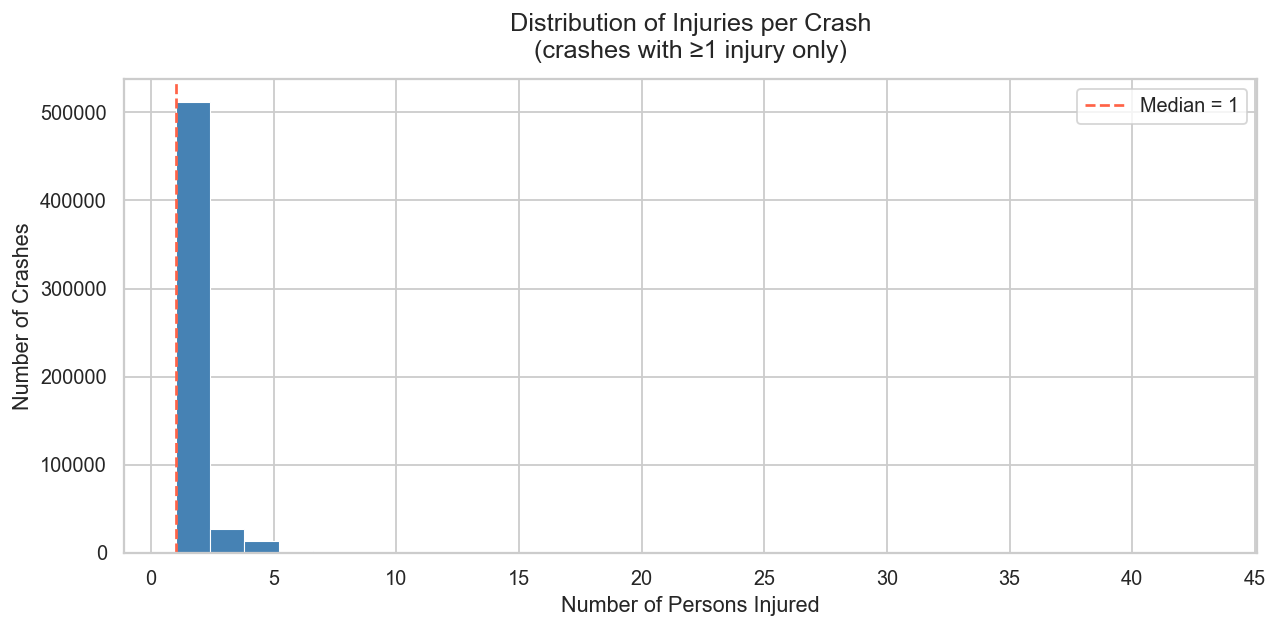

✓ Chart 1 saved


In [54]:
# CHART 1 — DISTRIBUTION: Injuries per Crash (Histogram)
"""
Question  : How are injuries distributed across all crashes?
Chart type: Histogram — best for showing the shape / skewness of a numeric variable.
Insight   : We expect most crashes to have 0 or 1 injury; rare extreme events
            will create a long right tail.
"""
fig, ax = plt.subplots()
crash_injuries = df[df['injured'] > 0]['injured']
ax.hist(crash_injuries, bins=30, color='steelblue', edgecolor='white', linewidth=0.6)
ax.set_title('Distribution of Injuries per Crash\n(crashes with ≥1 injury only)', pad=12)
ax.set_xlabel('Number of Persons Injured')
ax.set_ylabel('Number of Crashes')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
median_val = crash_injuries.median()
ax.axvline(median_val, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Median = {median_val:.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('../plot/chart1_injury_distribution.png', dpi=130)
plt.show()
print("✓ Chart 1 saved")

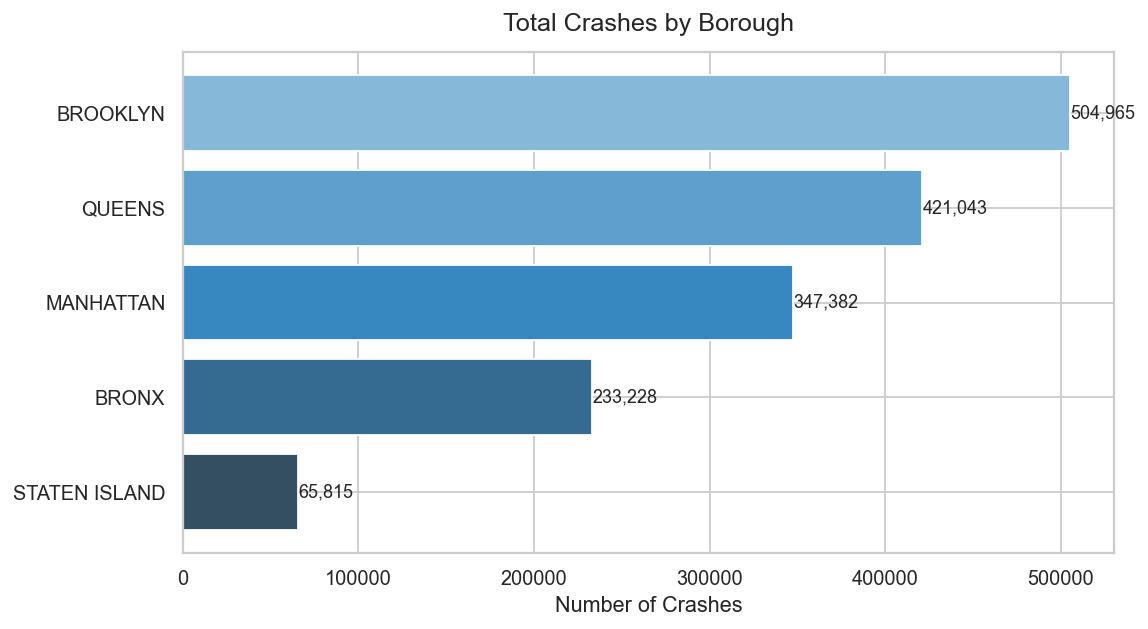

✓ Chart 2 saved


In [55]:
# CHART 2 — COMPARISON: Crashes by Borough (Bar Chart) 
"""
Question  : Which borough has the most crashes, and by how much?
Chart type: Horizontal bar chart — great for comparing a ranked categorical variable.
Insight   : Brooklyn and Queens lead; UNKNOWN (missing borough) is also sizable.
"""
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = borough_counts[borough_counts['borough'] != 'UNKNOWN']
colors = sns.color_palette("Blues_d", len(plot_data))
ax.barh(plot_data['borough'], plot_data['crashes'], color=colors)
ax.set_title('Total Crashes by Borough', pad=12)
ax.set_xlabel('Number of Crashes')
ax.invert_yaxis()
for i, (val, name) in enumerate(zip(plot_data['crashes'], plot_data['borough'])):
    ax.text(val + 200, i, f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../plot/chart2_crashes_by_borough.png', dpi=130)
plt.show()
print("✓ Chart 2 saved")


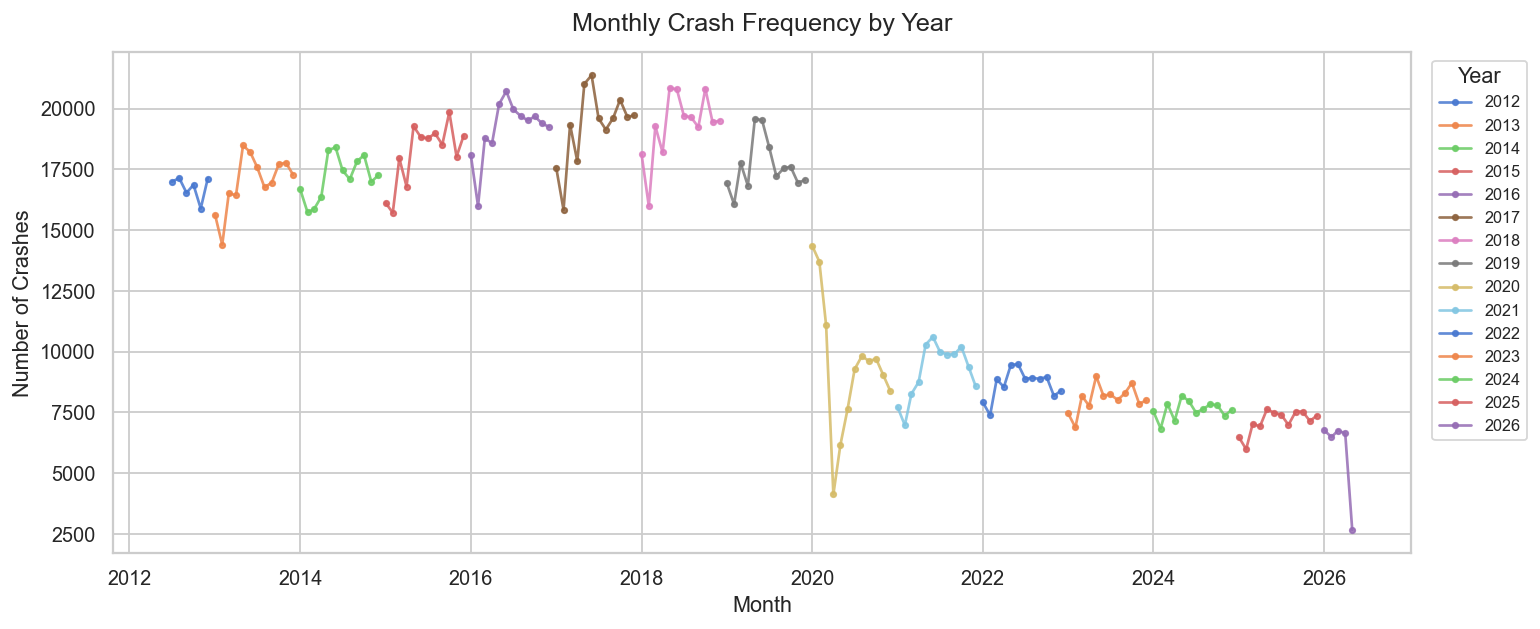

✓ Chart 3 saved


In [56]:

# CHART 3 — RELATIONSHIP: Crashes over Time (Line Chart) 
"""
Question  : Is there a trend in crash frequency over the years / months?
Chart type: Line chart — ideal for showing change over time.
Insight   : Look for seasonal peaks (summer? holidays?) and year-over-year changes
            (e.g., a COVID-era dip in 2020).
"""
monthly = (df.groupby(['year', 'month'])
             .size()
             .reset_index(name='crashes'))
monthly['date'] = pd.to_datetime(monthly[['year','month']].assign(day=1))

fig, ax = plt.subplots(figsize=(12, 5))
for yr, grp in monthly.groupby('year'):
    ax.plot(grp['date'], grp['crashes'], marker='o', markersize=3,
            linewidth=1.5, label=str(yr), alpha=0.85)
ax.set_title('Monthly Crash Frequency by Year', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Crashes')
ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../plot/chart3_crashes_over_time.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ Chart 3 saved")


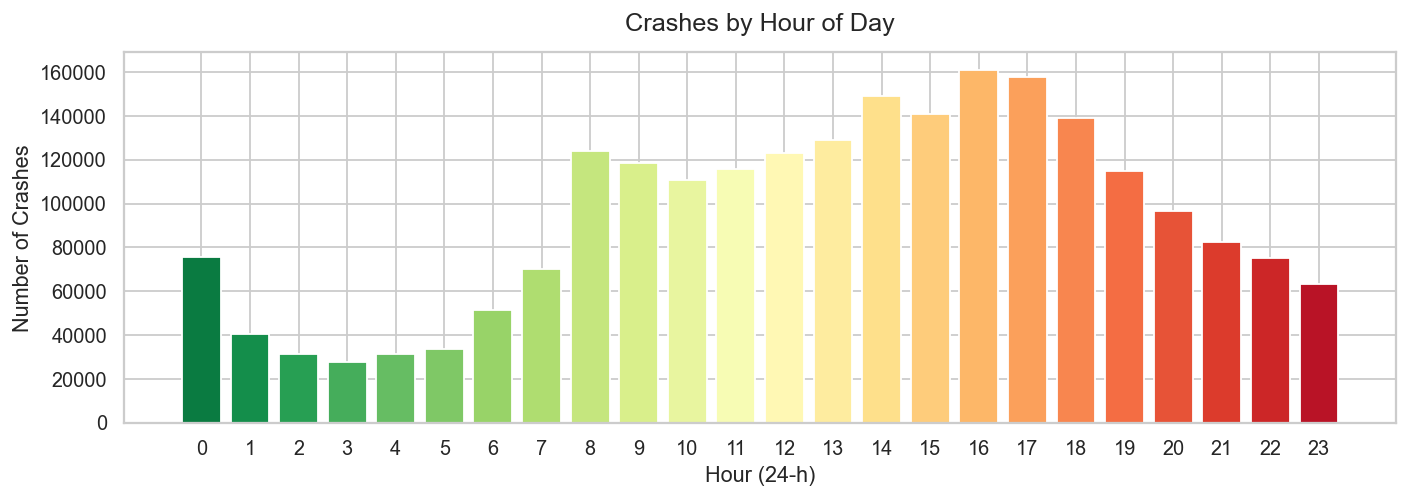

✓ Bonus Chart 4 saved


In [57]:
# BONUS: Crashes by Hour of Day 
"""
Question  : At what time of day do crashes peak?
Chart type: Bar chart on a cyclical x-axis — shows the 24-hour rhythm clearly.
Insight   : Rush-hour spikes expected around 8 AM and 5 PM.
"""
by_hour_all = df.groupby('hour').size().reset_index(name='crashes').dropna()
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(by_hour_all['hour'], by_hour_all['crashes'],
       color=sns.color_palette("RdYlGn_r", 24))
ax.set_title('Crashes by Hour of Day', pad=12)
ax.set_xlabel('Hour (24-h)')
ax.set_ylabel('Number of Crashes')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../plot/chart4_crashes_by_hour.png', dpi=130)
plt.show()
print("✓ Bonus Chart 4 saved")